# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [2]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.
from sklearn.impute import SimpleImputer

import time  # Module for time-related operations.
import math # to do math calculations

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

# **Loading the Data**

In [4]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# loading both the training and test sets
df = pd.read_csv("/content/drive/MyDrive/Train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Test.csv")
data = df.copy()
data_test = df_test.copy()

# **Data Overview**

* Observations

* Sanity checks

### Viewing the first and last 5 rows of the dataset

In [6]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [7]:
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [8]:
df.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


In [9]:
df_test.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
4995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
4996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
4997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
4998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
4999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


### Checking the shape of the dataset.

In [10]:
df.shape

(20000, 41)

* The training set has 20,000 rows and 41 columns.

In [11]:
df_test.shape

(5000, 41)

* The training set has 5000 rows and 41 columns.

### Checking the attribute types

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

* 41 numerical variables: All are float except Target, which is int.

In [13]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

* 41 numerical variables: All are float except Target, which is int.

### Checking the statistical summary

In [14]:
df.describe(include="all")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


- The dataset contains 20,000 observations and 41 variables.
- There are 40 independent variables (V1–V40) and 1 target variable (Target).
- All variables are numerical in nature.
- Columns V1 and V2 contain 18 missing values each, while all other columns have no missing values.
- The target variable is binary, containing values 0 and 1, indicating a classification problem.
- The target variable is imbalanced, with only about 5.55% positive cases (1s) and the majority belonging to class 0.
- Most variables have means close to zero, suggesting the data may already be standardized or transformed.
- Several variables show a large spread between minimum and maximum values, indicating the possible presence of outliers.
- The standard deviations vary across variables, showing differences in variability among features.
- Since the dataset is imbalanced, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC would be more appropriate than accuracy alone.

In [15]:
df_test.describe(include="all")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,...,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,...,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,...,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,...,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,...,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,...,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,...,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


- The dataset contains 5,000 observations and 41 variables.
- There are 40 independent variables (V1–V40) and 1 target variable (Target).
- All variables are numerical in nature.
- Column V1 contains 5 missing values and column V2 contains 6 missing values, while all other columns have complete data.
- The target variable is binary with values 0 and 1, indicating a classification problem.
- The target variable is imbalanced, with approximately 5.64% positive cases (1s) and the majority belonging to class 0.
- Most variables have means close to zero, suggesting the data may already be standardized or transformed.
- Several variables have large minimum and maximum values, indicating the possible presence of outliers.
- The standard deviations vary across variables, showing different levels of spread among the features.
- The distributions appear relatively centered around the median, though some variables may contain skewness and extreme values.
- Since the dataset is imbalanced, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC are more suitable than accuracy alone.

### Checking for missing values

In [16]:
df.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


* 18 missing values in V1 and V2.

In [17]:
df_test.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


* 5 missing values in V1.
* 6 missing values in V2.

### Checking for duplicate values

In [18]:
df.duplicated().sum()

np.int64(0)

* Zero duplicate values in training set.

In [19]:
df_test.duplicated().sum()

np.int64(0)

* Zero duplicate values in test set.

# **Exploratory Data Analysis**

## Univariate analysis

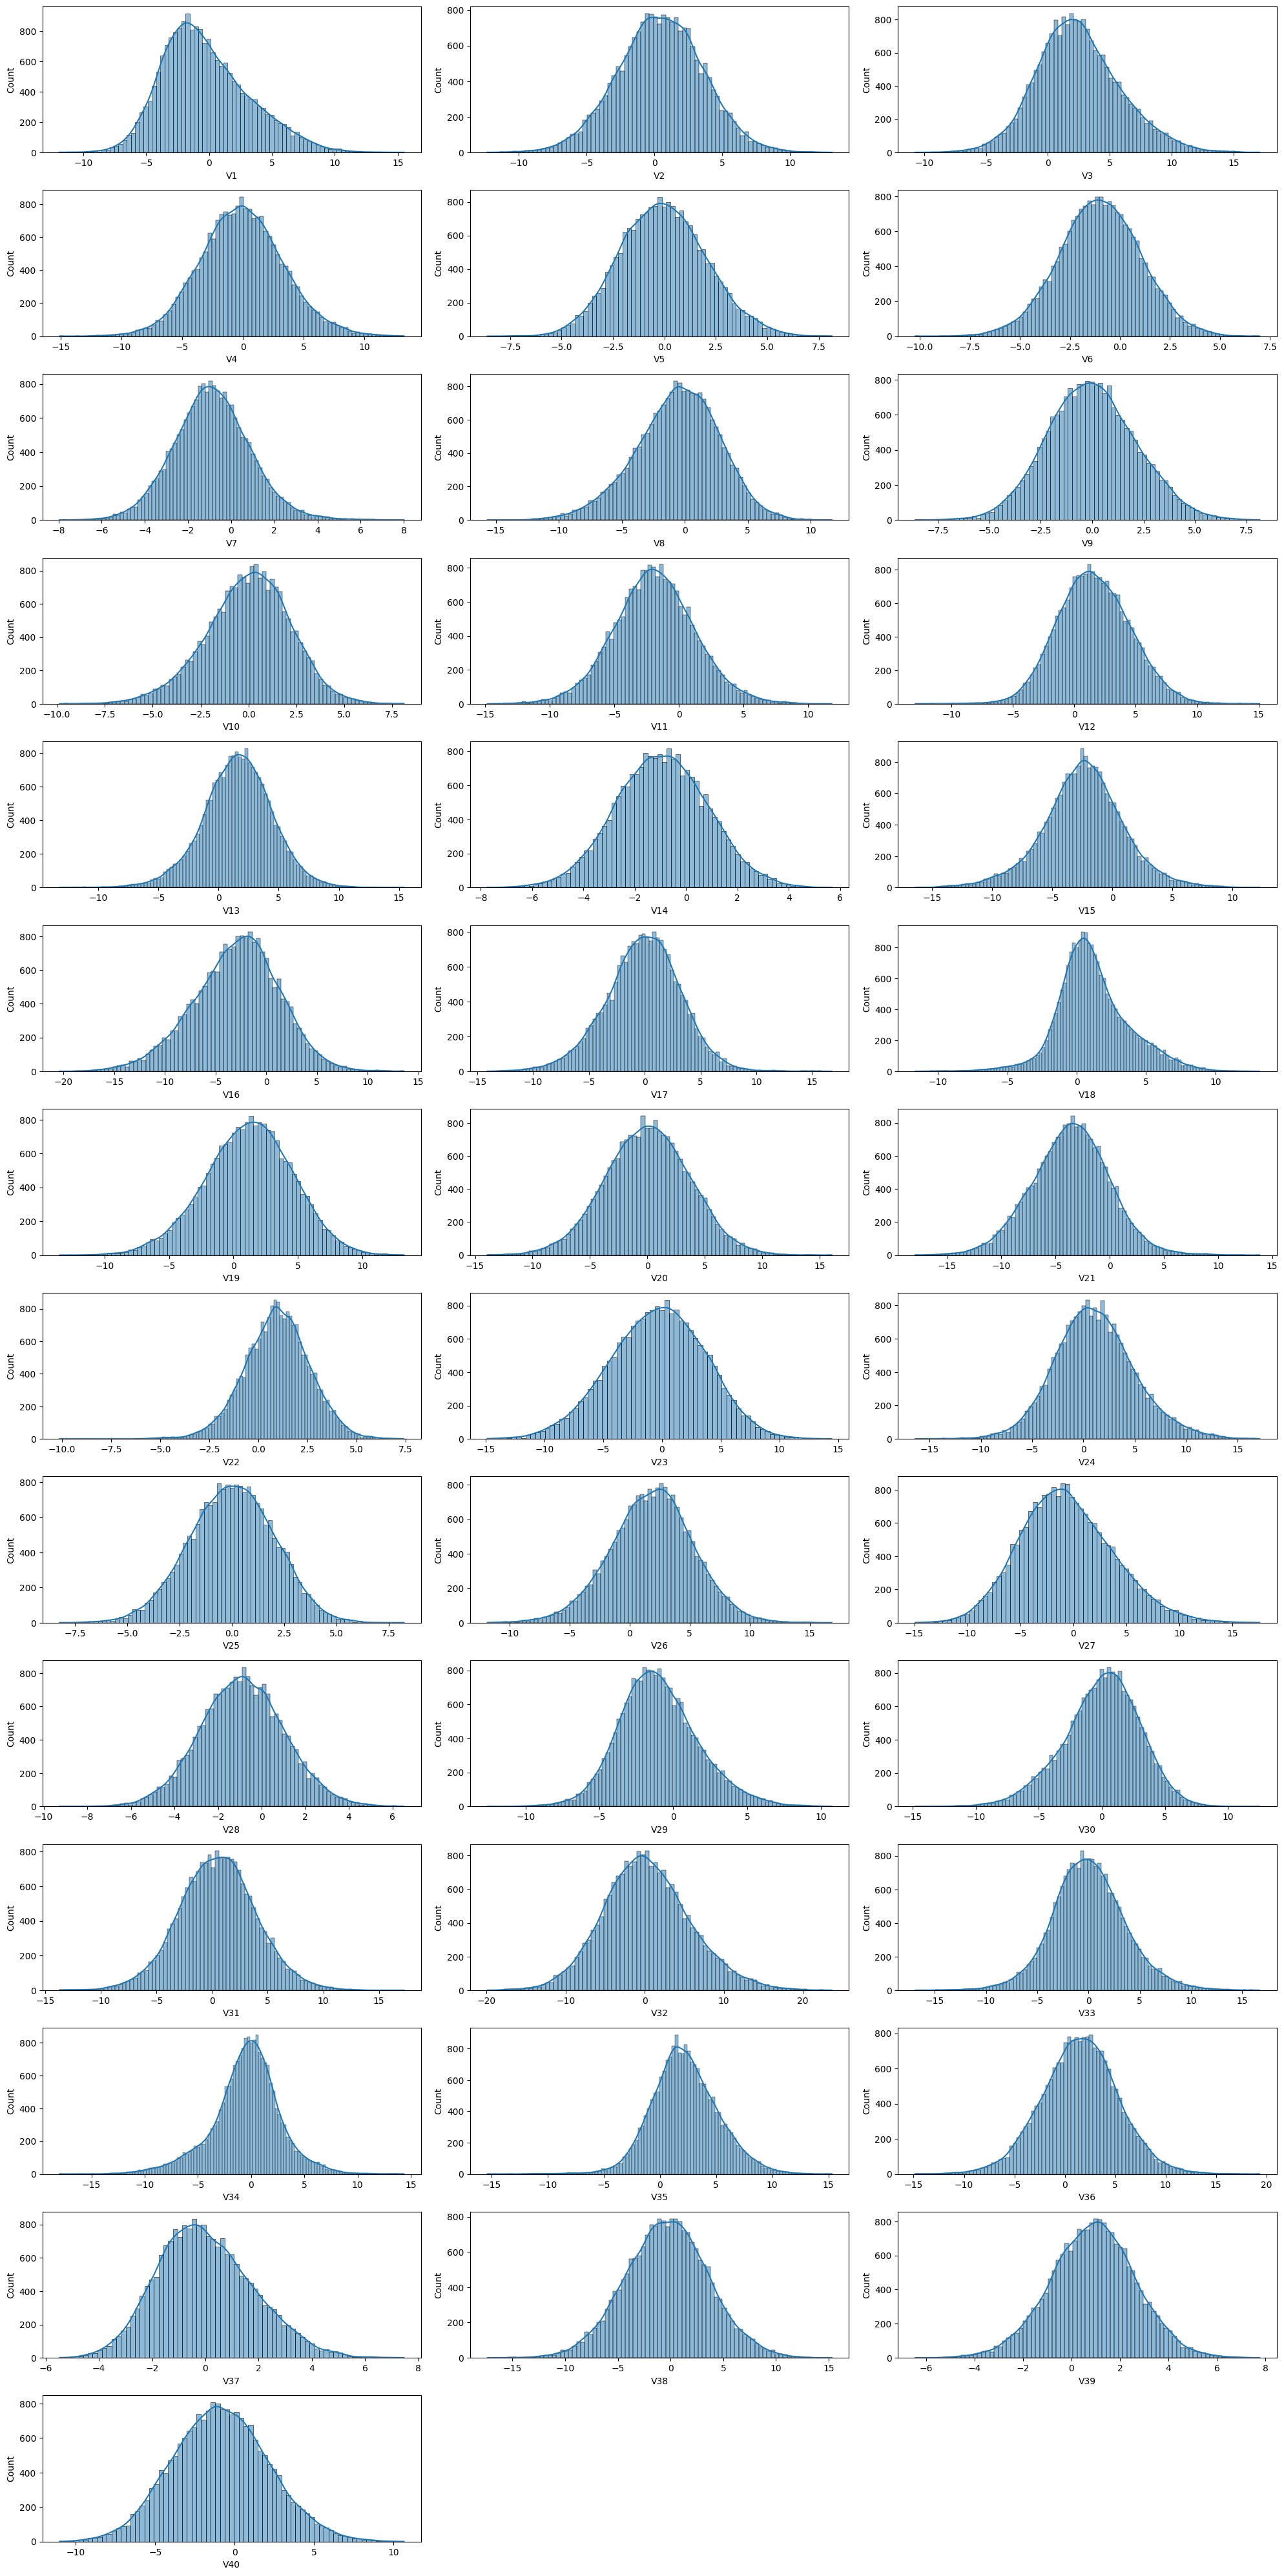

In [20]:
# selecting all numerical columns
num_features = df.select_dtypes(include=['float64']).columns

# setting figure size
plt.figure(figsize=(20, 40))

# plotting histograms for all numerical variables
for i, feature in enumerate(num_features):
    plt.subplot(len(num_features)//3 + 1, 3, i + 1)
    sns.histplot(data=df, x=feature, kde=True)

plt.tight_layout()
plt.show()

* The distributions are all fairly uniform.

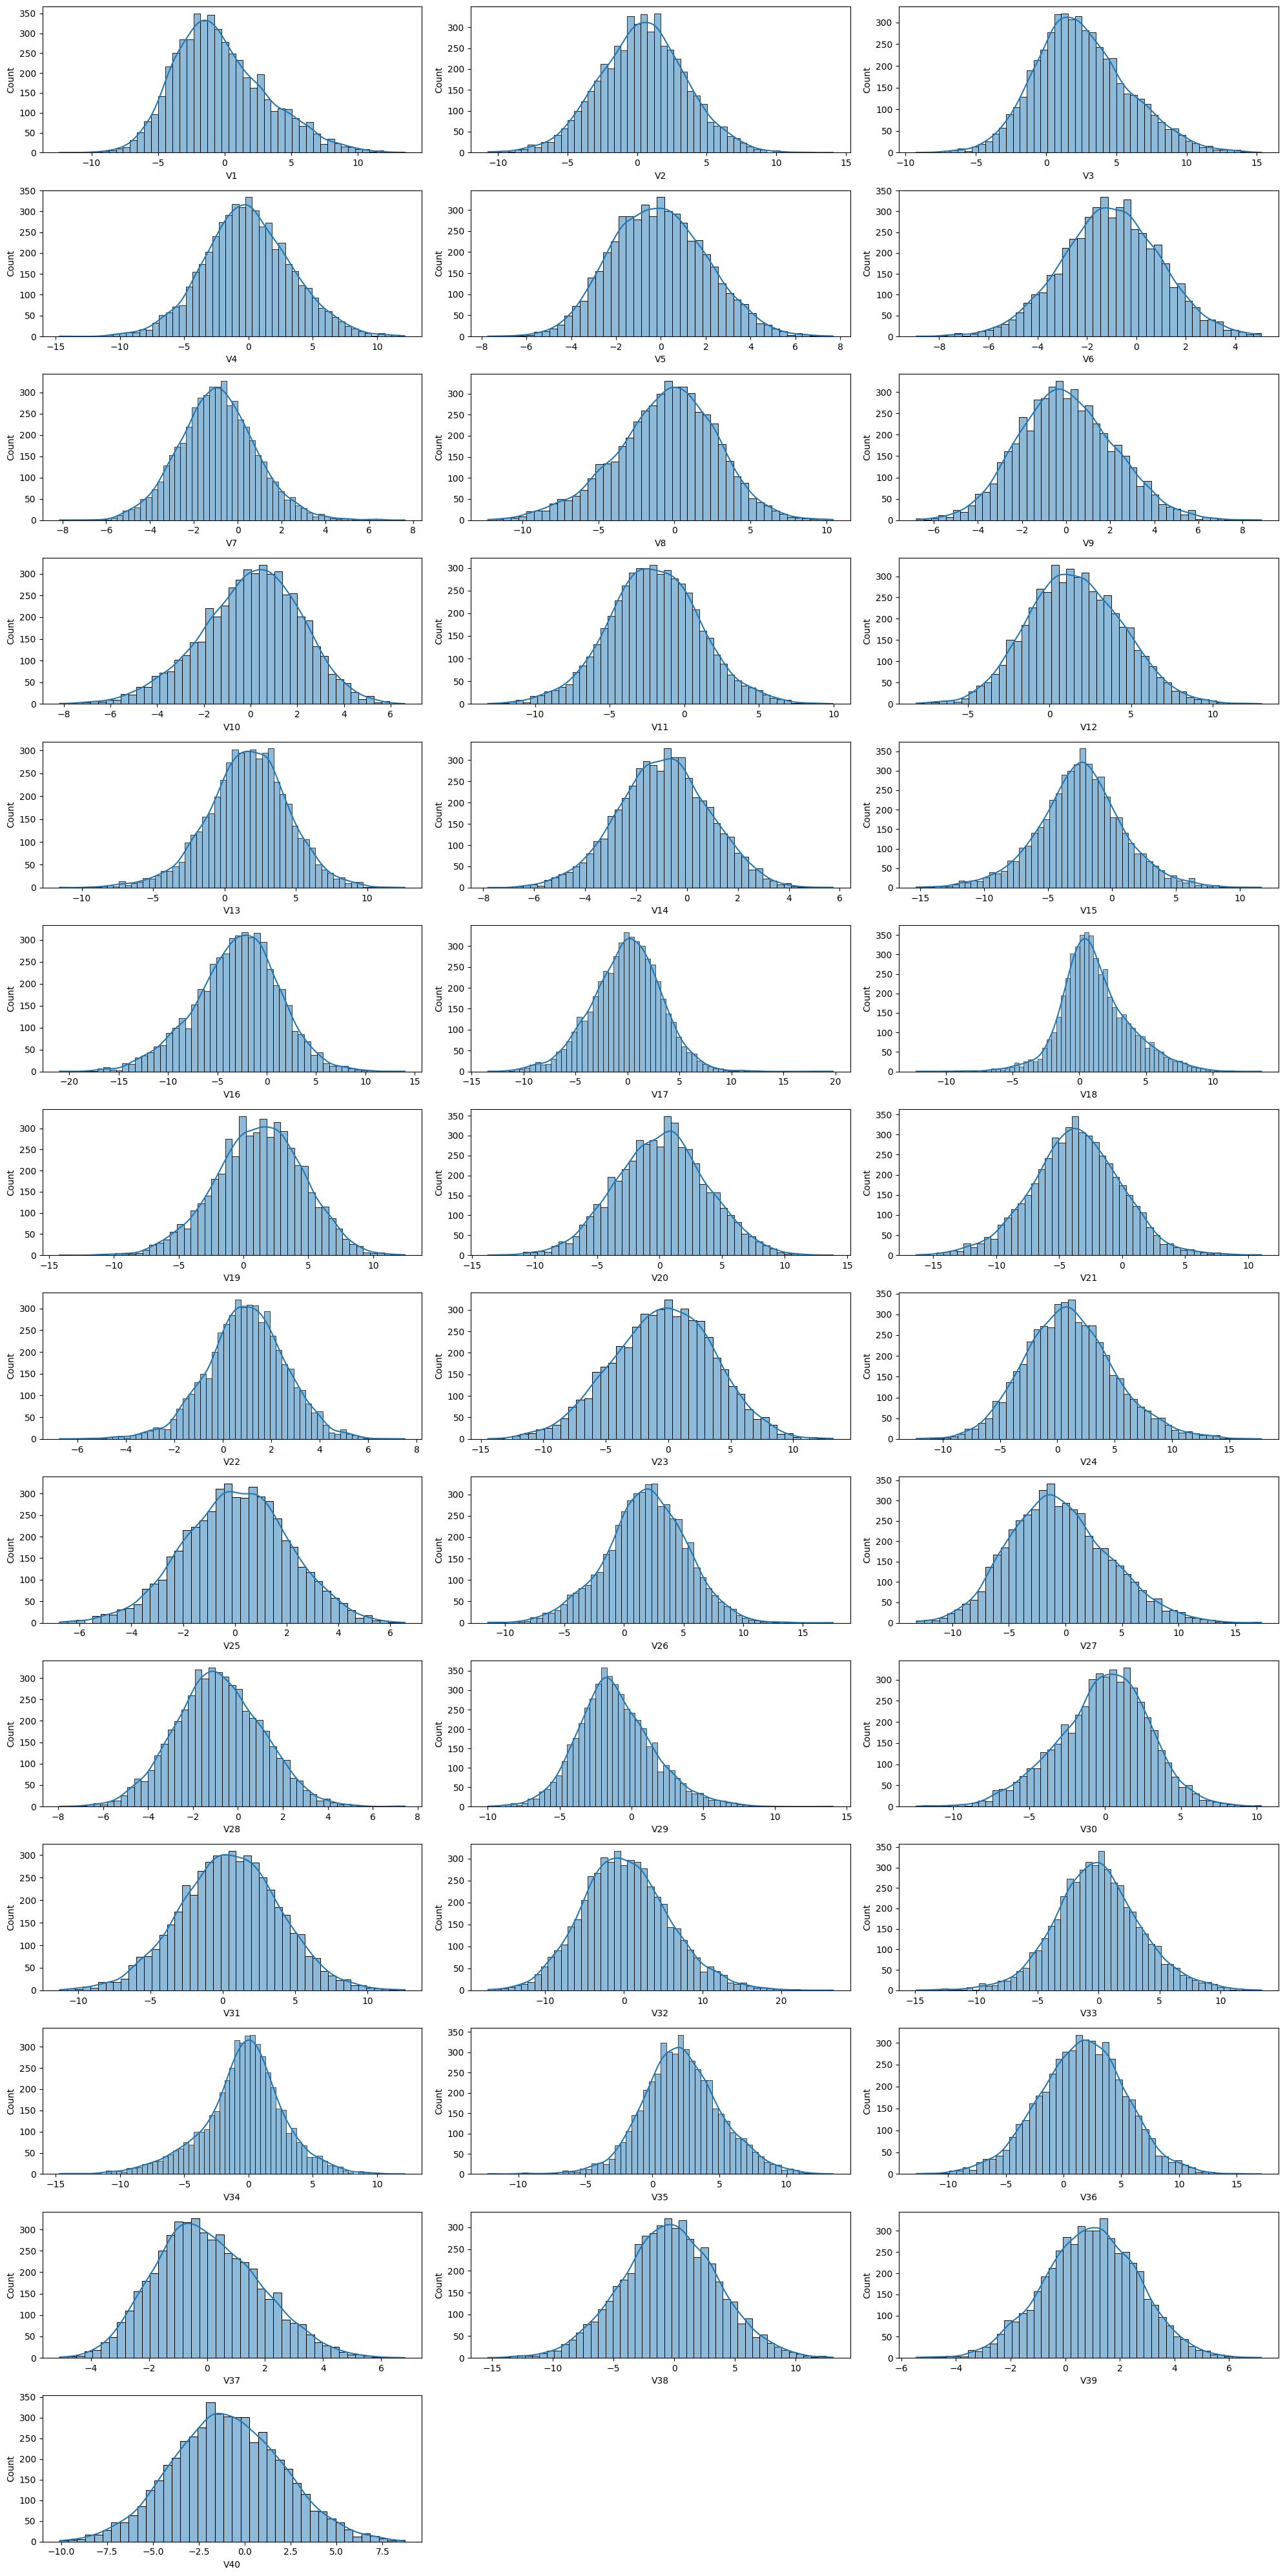

In [21]:
# selecting all numerical columns
num_features = df.select_dtypes(include=['float64']).columns

# setting figure size
plt.figure(figsize=(20, 40))

# plotting histograms for all numerical variables
for i, feature in enumerate(num_features):
    plt.subplot(len(num_features)//3 + 1, 3, i + 1)
    sns.histplot(data=df_test, x=feature, kde=True)

plt.tight_layout()
plt.show()

* The distributions are all fairly uniform.

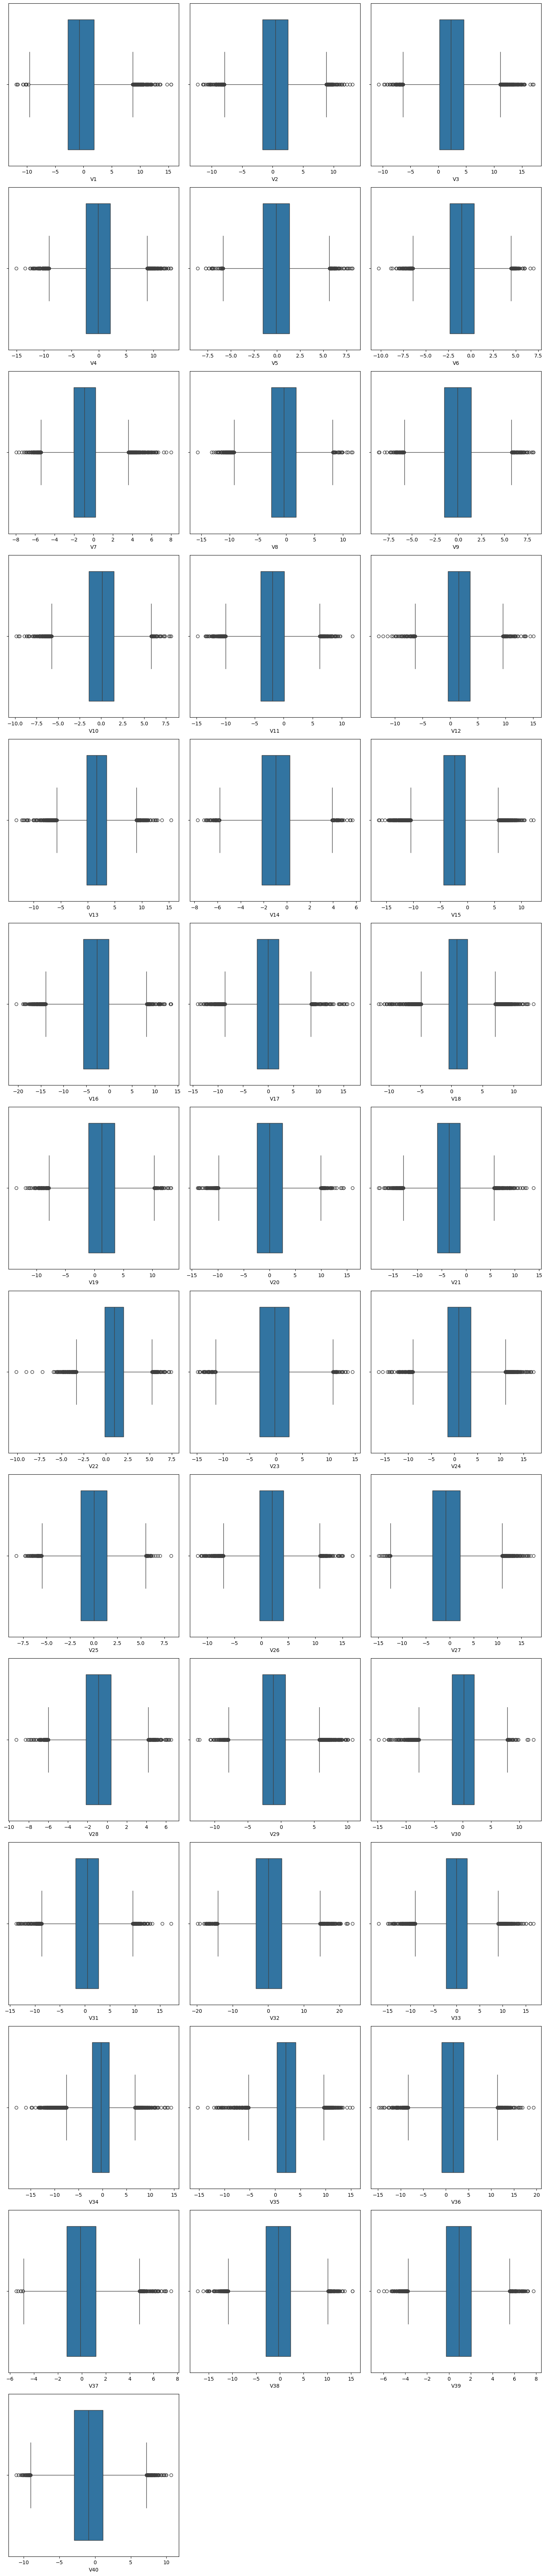

In [22]:
# number of columns in subplot grid
n_cols = 3

# calculating required rows
n_rows = math.ceil(len(num_features) / n_cols)

# figure size
plt.figure(figsize=(15, 5 * n_rows))

# plotting boxplots
for i, feature in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=data, x=feature)

plt.tight_layout()
plt.show()

* Multiple outliers on both sides of all variables.

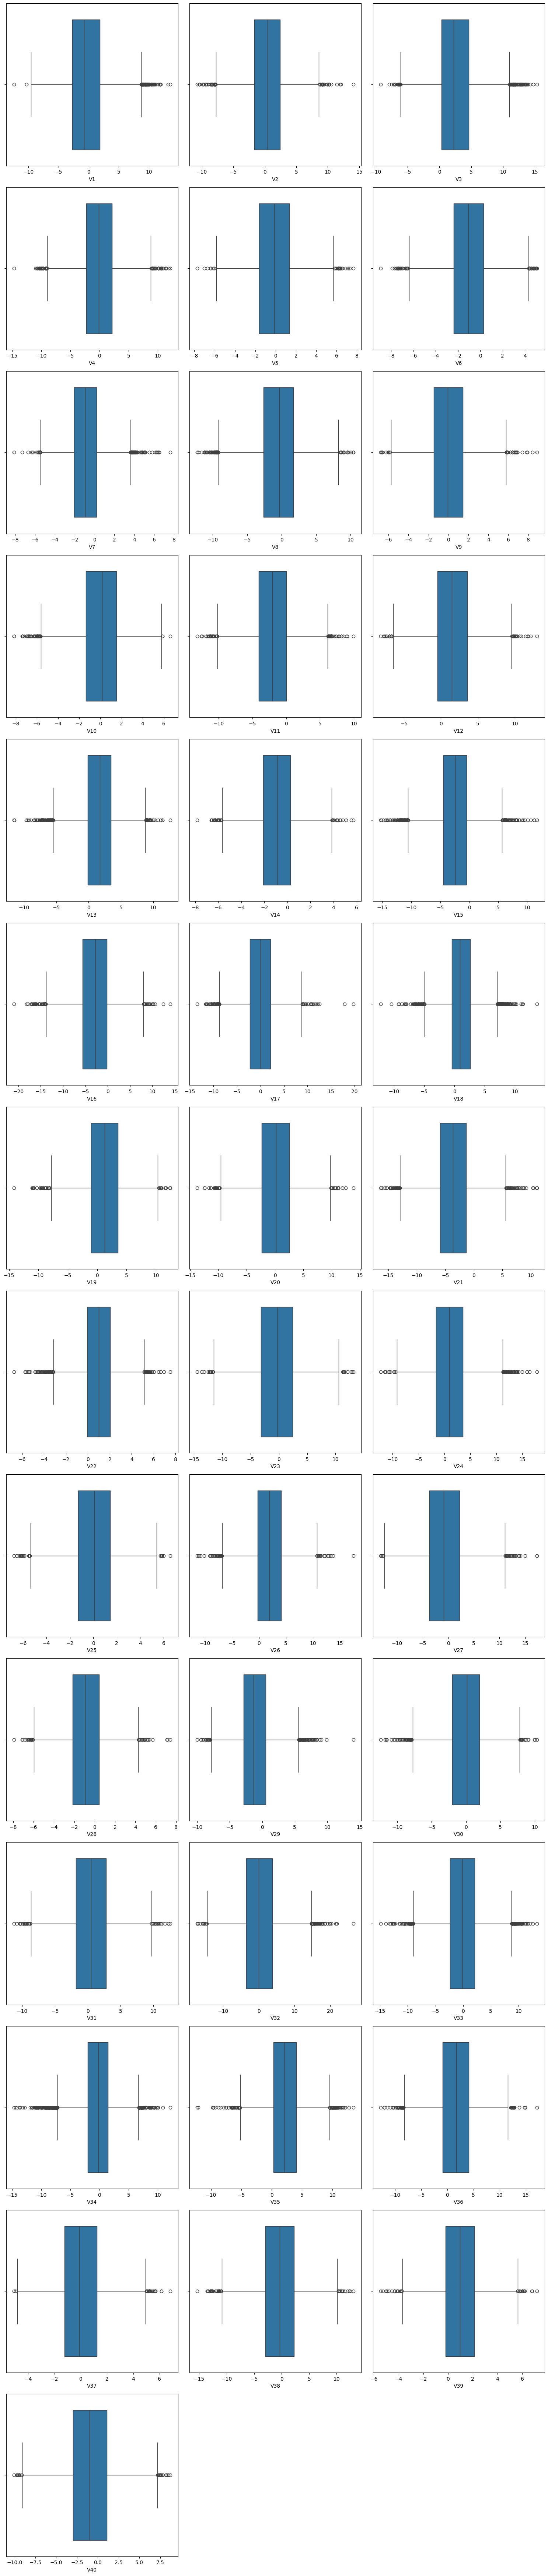

In [23]:
# number of columns in subplot grid
n_cols = 3

# calculating required rows
n_rows = math.ceil(len(num_features) / n_cols)

# figure size
plt.figure(figsize=(15, 5 * n_rows))

# plotting boxplots
for i, feature in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=data_test, x=feature)

plt.tight_layout()
plt.show()

* Multiple outliers on both sides of all variables.

Target
0    94.45
1     5.55
Name: proportion, dtype: float64 



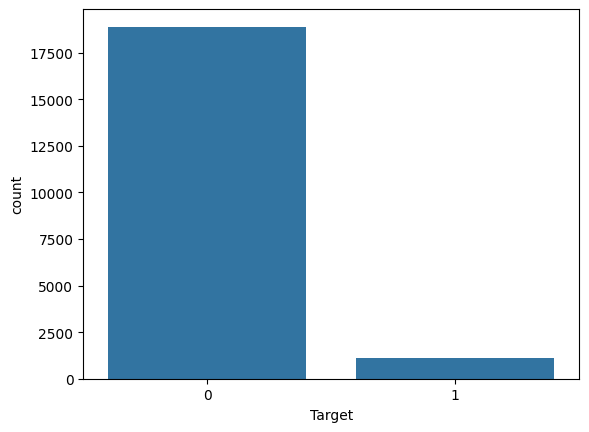

In [24]:
print(100*data['Target'].value_counts(normalize=True), '\n')
# checking the distribution of the categories in Case status

sns.countplot(data=data, x='Target');
# plotting the count plot for Case status

* About 5% are failures.

Target
0    94.36
1     5.64
Name: proportion, dtype: float64 



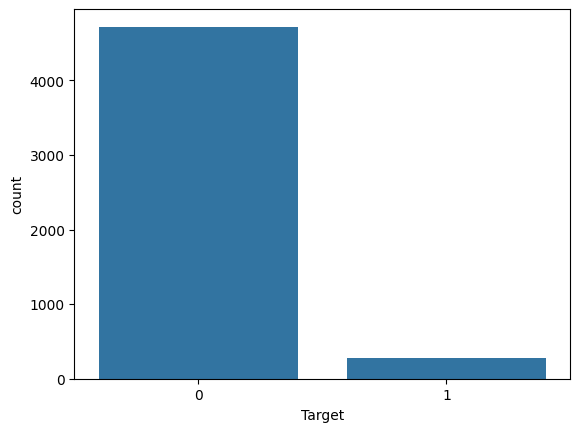

In [25]:
print(100*data_test['Target'].value_counts(normalize=True), '\n')
# checking the distribution of the categories in Case status

sns.countplot(data=data_test, x='Target');
# plotting the count plot for Case status

* About 5% are failures.

## Bivariate Analysis

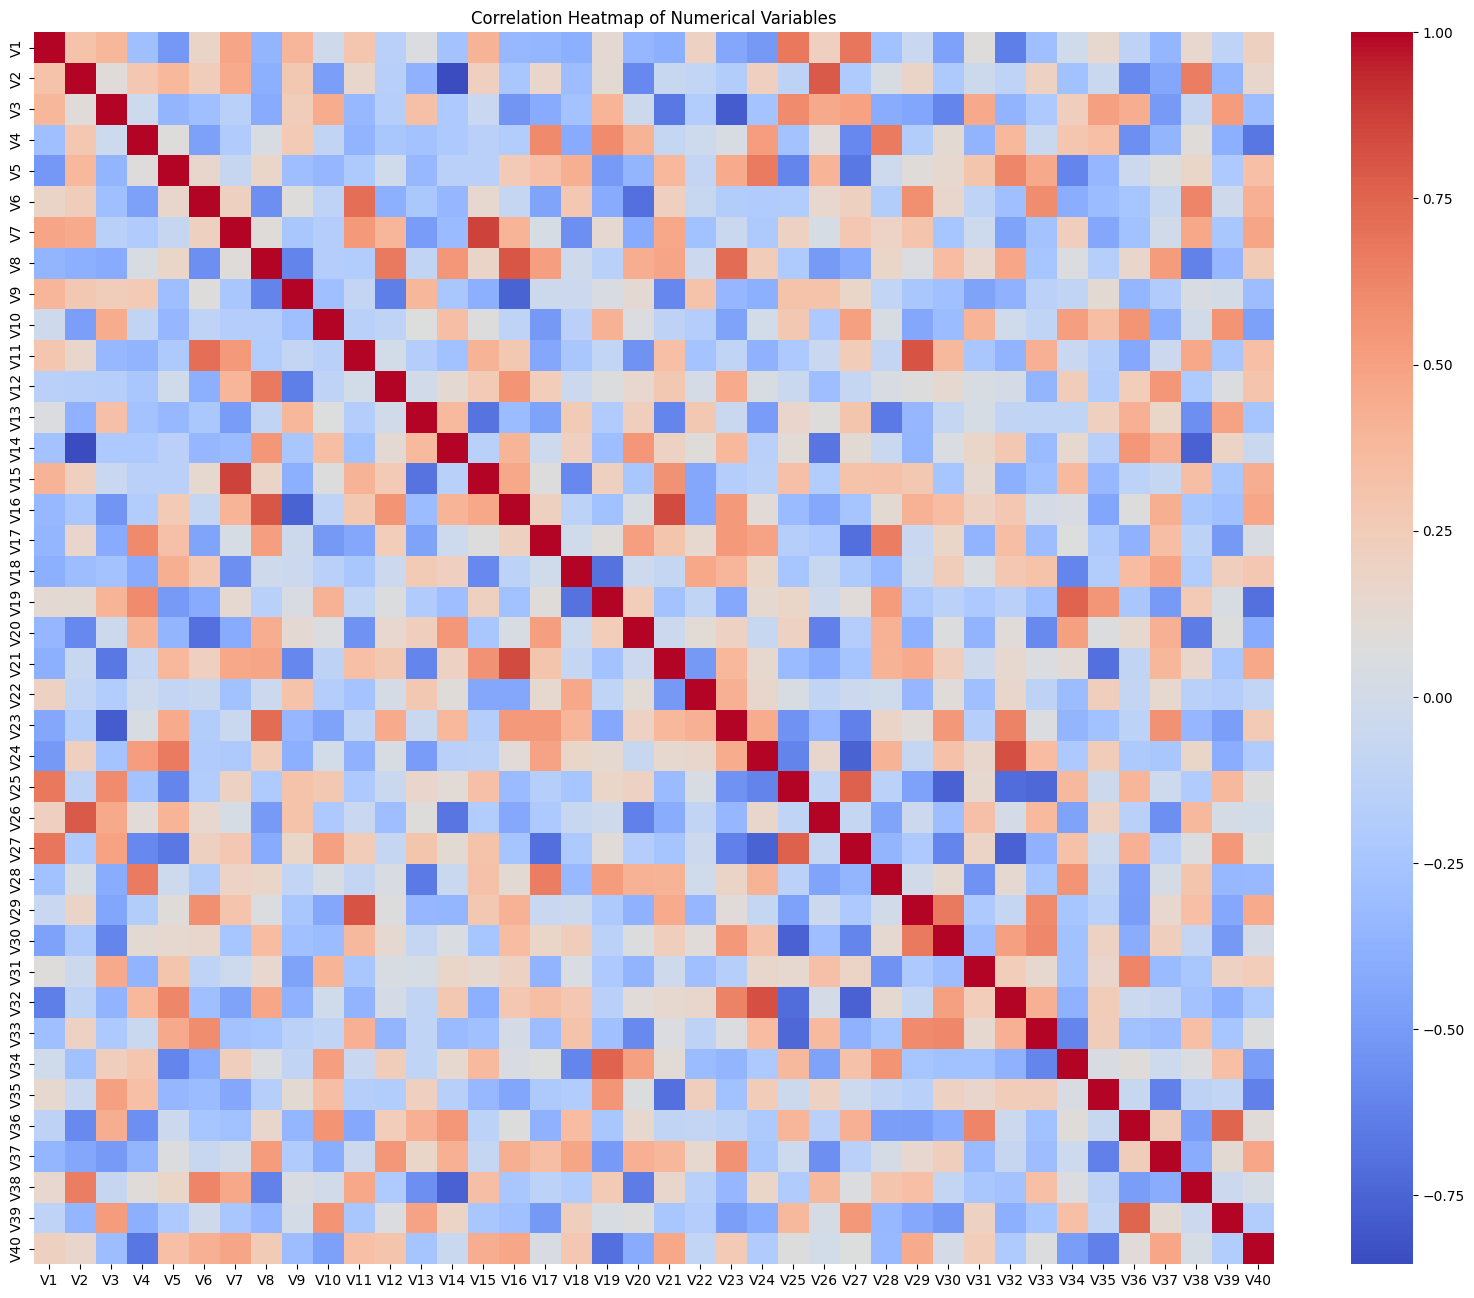

In [26]:
# selecting only feature columns
corr_data = data.drop('Target', axis=1)

# correlation matrix
corr_matrix = corr_data.corr()

# plotting heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()



* High correlations in a few variables.

In [27]:
# finding highly correlated pairs
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

# printing highly correlated pairs
for pair in high_corr:
    print(pair)

('V11', 'V6', np.float64(0.71048000818567))
('V14', 'V2', np.float64(-0.853530003549924))
('V15', 'V7', np.float64(0.8678709232567365))
('V16', 'V8', np.float64(0.8025054949614852))
('V16', 'V9', np.float64(-0.7529306316322203))
('V21', 'V16', np.float64(0.8365265817081083))
('V23', 'V3', np.float64(-0.7855798697210374))
('V23', 'V8', np.float64(0.7178583077804072))
('V26', 'V2', np.float64(0.7874399640890622))
('V27', 'V17', np.float64(-0.7065981525741186))
('V27', 'V24', np.float64(-0.75533474903169))
('V27', 'V25', np.float64(0.7662546130686906))
('V29', 'V11', np.float64(0.8112280237988402))
('V30', 'V25', np.float64(-0.7647341333374413))
('V32', 'V24', np.float64(0.8251193475710306))
('V32', 'V25', np.float64(-0.7110824040939223))
('V32', 'V27', np.float64(-0.7657326706650749))
('V33', 'V25', np.float64(-0.7351567466472084))
('V34', 'V19', np.float64(0.7561878867537044))
('V35', 'V21', np.float64(-0.7003995927544395))
('V38', 'V14', np.float64(-0.7626835389110217))
('V39', 'V36', 

# **Data Preprocessing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [28]:
# Dividing training data into x and y
X = data.drop(columns=["Target"], axis=1)
y = data["Target"]


In [29]:
# Splitting data into training and validation set:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [30]:
X_train.shape

(16000, 40)

In [31]:
X_val.shape

(4000, 40)

In [32]:
# Dividing test data into X_test and y_test
X_test = data_test.drop(columns=['Target'], axis=1)
y_test = data_test["Target"]

In [33]:
X_test.shape

(5000, 40)

In [34]:
# Create imputer object
imputer = SimpleImputer(strategy='median')

# Apply to numerical columns
X_train[num_features] = imputer.fit_transform(X_train[num_features])

# Use same median values on validation/test data
X_val[num_features] = imputer.transform(X_val[num_features])
X_test[num_features] = imputer.transform(X_test[num_features])

In [35]:
print(X_train.isna().sum())
print(X_val.isna().sum())
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V2

* No missing values in any of the datasets.

In [36]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# Converting all the y sets to numpy

# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

Since the objective is to predict turbine failures before they occur, the most important evaluation criterion is Recall for the failure class (1).

Recall measures the proportion of actual failures correctly identified by the model.

In this problem, a False Negative means the model fails to detect an actual generator failure, which results in expensive replacement costs. On the other hand, False Positives only lead to inspection costs, which are much lower.

Therefore, minimizing False Negatives is the highest priority, making Recall the most suitable evaluation metric.

F1-score can also be used as a secondary metric to maintain a balance between Recall and Precision.

In [37]:
# function to calculate classification metrics
def model_performance_classification(model, predictors, target):

    # predicted probabilities
    pred_prob = model.predict(predictors)

    # convert probabilities to binary predictions
    pred = (pred_prob > 0.5).astype(int)

    # flatten predictions
    pred = pred.flatten()

    # calculate metrics
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    # dataframe of metrics
    df_perf = pd.DataFrame({
        "Accuracy": acc,
        "Recall": recall,
        "Precision": precision,
        "F1": f1
    }, index=[0])

    return df_perf

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [38]:
# Building the neural network
model_0 = Sequential()

# Hidden layer
model_0.add(Dense(32, activation='relu', input_shape=(40,)))

# Output layer
model_0.add(Dense(1, activation='sigmoid'))

# Model summary
model_0.summary()

# Compiling the model
model_0.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['Recall']
)

epochs = 50
batch_size = 32



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - Recall: 0.4032 - loss: 0.1499 - val_Recall: 0.5901 - val_loss: 0.1063
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.6002 - loss: 0.0969 - val_Recall: 0.6577 - val_loss: 0.0894
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.6791 - loss: 0.0851 - val_Recall: 0.7072 - val_loss: 0.0813
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7083 - loss: 0.0786 - val_Recall: 0.7568 - val_loss: 0.0766
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7309 - loss: 0.0743 - val_Recall: 0.7793 - val_loss: 0.0733
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7477 - loss: 0.0710 - val_Recall: 0.7883 - val_loss: 0.0710
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7669 - loss: 0.0684 - val_Recall: 0.7928 - val_loss: 0.0690
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7770 - loss: 0.0663 - val_Recall: 0.7973 - val_loss: 0.0675
Epoch 9/

In [40]:
print("Time taken in seconds ",end-start)

Time taken in seconds  73.06414532661438


In [41]:
# Getting performance metrics for model_0
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.990437,0.843468,0.981651,0.907329


In [42]:
# Validation performance
model_0_val_perf = (model_performance_classification(model_0, X_val, y_val))
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.991,0.864865,0.969697,0.914286


# **Model Performance Improvement**

## Model 1

* Adding another layer to improve model performance.

In [43]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [44]:
# Initializing the neural network
model_1 = Sequential()

# First hidden layer
model_1.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))

# Second hidden layer
model_1.add(Dense(16, activation="relu"))

# Output layer
model_1.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used

# compiling model

model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [47]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.1937 - loss: 0.1775 - val_Recall: 0.4324 - val_loss: 0.1243
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.5090 - loss: 0.1088 - val_Recall: 0.6486 - val_loss: 0.1018
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.6419 - loss: 0.0921 - val_Recall: 0.7207 - val_loss: 0.0908
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6982 - loss: 0.0822 - val_Recall: 0.7658 - val_loss: 0.0837
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7331 - loss: 0.0756 - val_Recall: 0.7748 - val_loss: 0.0786
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7658 - loss: 0.0709 - val_Recall: 0.7793 - val_loss: 0.0747
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7838 - loss: 0.0673 - val_Recall: 0.7928 - val_loss: 0.0715
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7860 - loss: 0.0644 - val_Recall: 0.8108 - val_loss: 0.0687
Epoch 9/

In [48]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [49]:
# Getting performance metrics for model_1
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.992313,0.876126,0.983565,0.926742


In [50]:
# Validation performance
model_1_val_perf = (model_performance_classification(model_1, X_val, y_val))
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.99075,0.873874,0.955665,0.912941


## Model 2

* Use Adam instead of SGD.

In [51]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [52]:
# Initializing the neural network
model_2 = Sequential()

# Hidden layers
model_2.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))
model_2.add(Dense(16, activation="relu"))

# Output layer
model_2.add(Dense(1, activation="sigmoid"))

# Compiling the model with Adam optimizer
model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Recall"]
)

# Training the model
history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.5901 - loss: 0.1033 - val_Recall: 0.8153 - val_loss: 0.0746
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.7872 - loss: 0.0628 - val_Recall: 0.8649 - val_loss: 0.0614
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.8277 - loss: 0.0554 - val_Recall: 0.8784 - val_loss: 0.0577
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8435 - loss: 0.0514 - val_Recall: 0.8829 - val_loss: 0.0546
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8547 - loss: 0.0483 - val_Recall: 0.8874 - val_loss: 0.0524
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8626 - loss: 0.0462 - val_Recall: 0.8874 - val_loss: 0.0503
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8649 - loss: 0.0447 - val_Recall: 0.8829 - val_loss: 0.0491
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8671 - loss: 0.0431 - val_Recall: 0.8739 - val_loss: 0.0487
Epoch 9/50
500/500 

In [53]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,573 (21.77 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,716 (14.52 KB)

In [54]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [55]:
# Getting performance metrics for model_2
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.993563,0.922297,0.960141,0.940839


In [56]:
# Validation performance
model_2_val_perf = (model_performance_classification(model_2, X_val, y_val))
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.988,0.900901,0.884956,0.892857


## Model 3

* Now, we increase the number of neurons.

In [57]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [58]:
# Initializing Model 3
model_3 = Sequential()

# Increasing number of neurons
model_3.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))
model_3.add(Dense(32, activation="relu"))

# Output layer
model_3.add(Dense(1, activation="sigmoid"))

# Compile the model
model_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Recall"]
)

# Train the model
history_3 = model_3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.6565 - loss: 0.0971 - val_Recall: 0.8423 - val_loss: 0.0676
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8086 - loss: 0.0580 - val_Recall: 0.8649 - val_loss: 0.0587
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8480 - loss: 0.0514 - val_Recall: 0.8739 - val_loss: 0.0548
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8570 - loss: 0.0476 - val_Recall: 0.8739 - val_loss: 0.0514
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8682 - loss: 0.0454 - val_Recall: 0.8874 - val_loss: 0.0494
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8727 - loss: 0.0434 - val_Recall: 0.8874 - val_loss: 0.0485
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8784 - loss: 0.0419 - val_Recall: 0.8919 - val_loss: 0.0484
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.8818 - loss: 0.0408 - val_Recall: 0.8964 - val_loss: 0.0480
Epoch 9/50
500/500 

In [59]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [60]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [61]:
# Getting performance metrics for model_3
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.994375,0.95045,0.948315,0.949381


In [62]:
# Validation performance
model_3_val_perf = (model_performance_classification(model_3, X_val, y_val))
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.98725,0.900901,0.873362,0.886918


## Model 4

* Dropout regularization where we turn off 20% of all neurons.

In [63]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [64]:
# Initializing Model 4
model_4 = Sequential()

# Hidden layers with dropout
model_4.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))
model_4.add(Dropout(0.2))

model_4.add(Dense(32, activation="relu"))
model_4.add(Dropout(0.2))

# Output layer
model_4.add(Dense(1, activation="sigmoid"))

# Compile the model
model_4.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Recall"]
)

# Train the model
history_4 = model_4.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.5034 - loss: 0.1305 - val_Recall: 0.7838 - val_loss: 0.0755
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.7286 - loss: 0.0804 - val_Recall: 0.8423 - val_loss: 0.0614
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.7838 - loss: 0.0692 - val_Recall: 0.8559 - val_loss: 0.0562
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.7905 - loss: 0.0656 - val_Recall: 0.8559 - val_loss: 0.0545
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8164 - loss: 0.0639 - val_Recall: 0.8649 - val_loss: 0.0526
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8063 - loss: 0.0620 - val_Recall: 0.8784 - val_loss: 0.0490
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8232 - loss: 0.0573 - val_Recall: 0.8739 - val_loss: 0.0478
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8356 - loss: 0.0545 - val_Recall: 0.8874 - val_loss: 0.0458
Epoch 9/50
500/500 

In [65]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [66]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [67]:
# Getting performance metrics for model_4
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.993938,0.89527,0.994994,0.942501


In [68]:
# Validation performance
model_4_val_perf = (model_performance_classification(model_4, X_val, y_val))
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.9925,0.905405,0.957143,0.930556


## Model 5

* Change activation function to tanh.

In [69]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [70]:
# Initializing Model 5
model_5 = Sequential()

# Hidden layers with tanh activation
model_5.add(Dense(64, activation="tanh", input_dim=X_train.shape[1]))
model_5.add(Dense(32, activation="tanh"))

# Output layer
model_5.add(Dense(1, activation="sigmoid"))

# Compile the model
model_5.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Recall"]
)

# Train the model
history_5 = model_5.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - Recall: 0.6678 - loss: 0.1161 - val_Recall: 0.7252 - val_loss: 0.0715
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7590 - loss: 0.0655 - val_Recall: 0.7883 - val_loss: 0.0602
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7973 - loss: 0.0567 - val_Recall: 0.8153 - val_loss: 0.0548
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8097 - loss: 0.0512 - val_Recall: 0.8153 - val_loss: 0.0513
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8311 - loss: 0.0469 - val_Recall: 0.8198 - val_loss: 0.0494
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8480 - loss: 0.0432 - val_Recall: 0.8378 - val_loss: 0.0486
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8626 - loss: 0.0402 - val_Recall: 0.8514 - val_loss: 0.0479
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.8761 - loss: 0.0379 - val_Recall: 0.8784 - val_loss: 0.0468
Epoch 9/50
500/500 

In [71]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [72]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [73]:
# Getting performance metrics for model_5
model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.998625,0.977477,0.997701,0.987486


In [74]:
# Validation performance
model_5_val_perf = (model_performance_classification(model_5, X_val, y_val))
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.99125,0.891892,0.947368,0.918794


## Model 6

In [75]:
# clear the current Keras session
tf.keras.backend.clear_session()

In [76]:
# Initializing Model 6
model_6 = Sequential()

# Hidden layers
model_6.add(Dense(64, activation="relu", input_dim=X_train.shape[1]))
model_6.add(Dense(32, activation="relu"))

# Output layer
model_6.add(Dense(1, activation="sigmoid"))

# Compile model
model_6.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["Recall"]
)

# Define class weights
class_weights = {0:1, 1:5}

# Train model
history_6 = model_6.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - Recall: 0.7838 - loss: 0.2580 - val_Recall: 0.8964 - val_loss: 0.1213
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8716 - loss: 0.1800 - val_Recall: 0.8964 - val_loss: 0.0991
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8829 - loss: 0.1606 - val_Recall: 0.9009 - val_loss: 0.0963
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8896 - loss: 0.1489 - val_Recall: 0.9009 - val_loss: 0.0872
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8953 - loss: 0.1403 - val_Recall: 0.9054 - val_loss: 0.0835
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8975 - loss: 0.1344 - val_Recall: 0.9099 - val_loss: 0.0817
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8986 - loss: 0.1288 - val_Recall: 0.9144 - val_loss: 0.0809
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.9054 - loss: 0.1242 - val_Recall: 0.9144 - val_loss: 0.0845
Epoch 9/50
500/500 

In [77]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,213 (55.52 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,476 (37.02 KB)

In [78]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.1062240600586


In [79]:
# Getting performance metrics for model_6
model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.986437,0.987613,0.809788,0.889904


In [80]:
# Validation performance
model_6_val_perf = (model_performance_classification(model_6, X_val, y_val))
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.97475,0.900901,0.716846,0.798403


# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [81]:
# training performance comparison
train_perf = pd.concat(
    [
        model_0_train_perf,
        model_1_train_perf,
        model_2_train_perf,
        model_3_train_perf,
        model_4_train_perf,
        model_5_train_perf,
        model_6_train_perf
    ],
    axis=0
)

# validation performance comparison
val_perf = pd.concat(
    [
        model_0_val_perf,
        model_1_val_perf,
        model_2_val_perf,
        model_3_val_perf,
        model_4_val_perf,
        model_5_val_perf,
        model_6_val_perf
    ],
    axis=0
)

In [82]:
train_perf.index = [
    "Model_0",
    "Model_1",
    "Model_2",
    "Model_3",
    "Model_4",
    "Model_5",
    "Model_6"
]

val_perf.index = [
    "Model_0",
    "Model_1",
    "Model_2",
    "Model_3",
    "Model_4",
    "Model_5",
    "Model_6"
]

In [83]:
print("Training Performance")
print(train_perf)

print("\nValidation Performance")
print(val_perf)

Training Performance
         Accuracy    Recall  Precision        F1
Model_0  0.990437  0.843468   0.981651  0.907329
Model_1  0.992313  0.876126   0.983565  0.926742
Model_2  0.993563  0.922297   0.960141  0.940839
Model_3  0.994375  0.950450   0.948315  0.949381
Model_4  0.993938  0.895270   0.994994  0.942501
Model_5  0.998625  0.977477   0.997701  0.987486
Model_6  0.986437  0.987613   0.809788  0.889904

Validation Performance
         Accuracy    Recall  Precision        F1
Model_0   0.99100  0.864865   0.969697  0.914286
Model_1   0.99075  0.873874   0.955665  0.912941
Model_2   0.98800  0.900901   0.884956  0.892857
Model_3   0.98725  0.900901   0.873362  0.886918
Model_4   0.99250  0.905405   0.957143  0.930556
Model_5   0.99125  0.891892   0.947368  0.918794
Model_6   0.97475  0.900901   0.716846  0.798403


* The best model is model_4 since it has the highest validation recall, and fares better than model_3 on other metrics.

In [84]:
best_model = model_4

Now, let's check the performance of the final model on the test set.

In [85]:
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.9914,0.861702,0.983806,0.918715


In [86]:
y_test_pred_best = best_model.predict(X_test)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [87]:
# function to generate classification report
def generate_classification_report(model, predictors, target):

    # predicted probabilities
    pred_prob = model.predict(predictors)

    # convert probabilities to binary predictions
    pred = (pred_prob > 0.5).astype(int)

    # flatten predictions
    pred = pred.flatten()

    # print classification report
    print(classification_report(target, pred))

In [88]:
print("Classification Report - Train Data\n")
generate_classification_report(model_4, X_train, y_train)

print("Classification Report - Validation Data\n")
generate_classification_report(model_4, X_val, y_val)

print("Classification Report - Test Data\n")
generate_classification_report(model_4, X_test, y_test)

Classification Report - Train Data

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15112
           1       0.99      0.90      0.94       888

    accuracy                           0.99     16000
   macro avg       0.99      0.95      0.97     16000
weighted avg       0.99      0.99      0.99     16000

Classification Report - Validation Data

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.96      0.91      0.93       222

    accuracy                           0.99      4000
   macro avg       0.98      0.95      0.96      4000
weighted avg       0.99      0.99      0.99      4000

Classification Report - Test Data

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4718
  

# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

The final selected model demonstrated strong and consistent performance across the training, validation, and test datasets.

On the test set, the model achieved a recall of 86%, indicating that it correctly identified most turbine failures. The model also achieved very high precision (98%), meaning that nearly all predicted failures were actual failures.

Additionally, the similarity between training, validation, and test performance suggests that the model generalizes well and does not suffer from significant overfitting.

Overall, the model is effective for predictive maintenance as it can successfully identify turbine failures while minimizing unnecessary inspections.